# 1 Dataset Setup & Preprocessing

## Load and Inspect

In [32]:
# Load dataset

from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()

In [33]:
#description of the dataset

print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [34]:
# Shape of dataset
print(california.data.shape)
print(california.target.shape)

(20640, 8)
(20640,)


In [35]:
#load the feature names
california.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [36]:
# Make one dataframe of features and target

import pandas as pd

pd.set_option('display.precision', 4)
pd.set_option('display.max_columns', 9)
pd.set_option('display.width', None)
california_df = pd.DataFrame(california.data,
                             columns=california.feature_names)
california_df['MedHouseValue'] = pd.Series(california.target)
california_df.head()
california_df.to_csv("california.csv")

In [7]:
# Statistics description
import pandas as pd

california_df = pd.read_csv("california.csv", index_col=0)
california_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


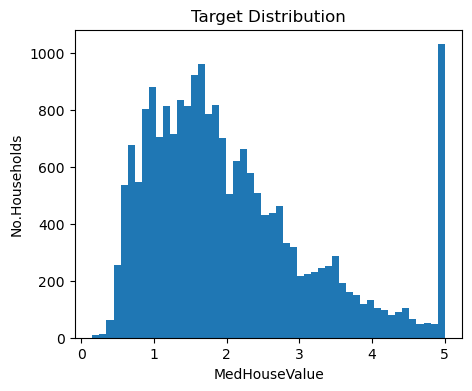

In [39]:
# Target distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
plt.hist(x=california_df["MedHouseValue"], bins=50)
plt.title("Target Distribution")
plt.xlabel("MedHouseValue")
plt.ylabel("No.Households")
plt.show()

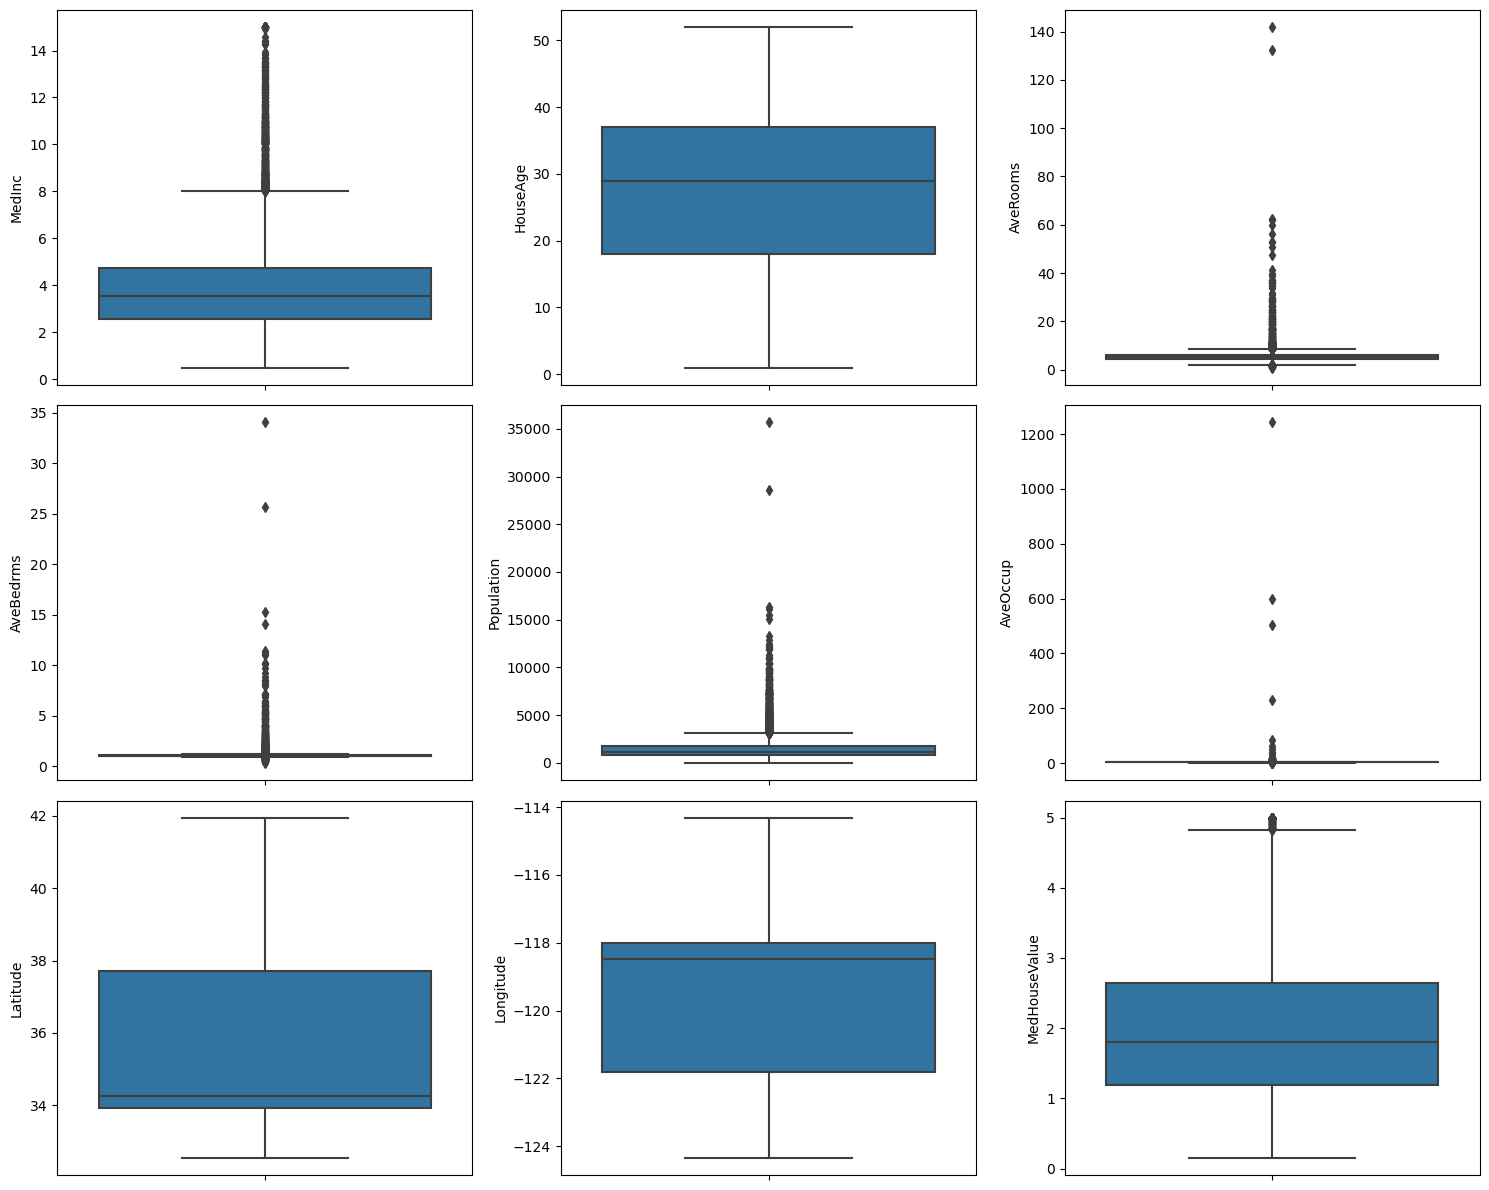

In [19]:
# check boxplots for outliers
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_cols = california_df.select_dtypes(include=np.number).columns
n = 3

rows = int(np.ceil(len(num_cols) / n))

plt.figure(figsize=(n*5, rows*4))

for i, col in enumerate(num_cols):
    plt.subplot(rows, n, i+1)
    sns.boxplot(y=california_df[col])

plt.tight_layout()
plt.show()

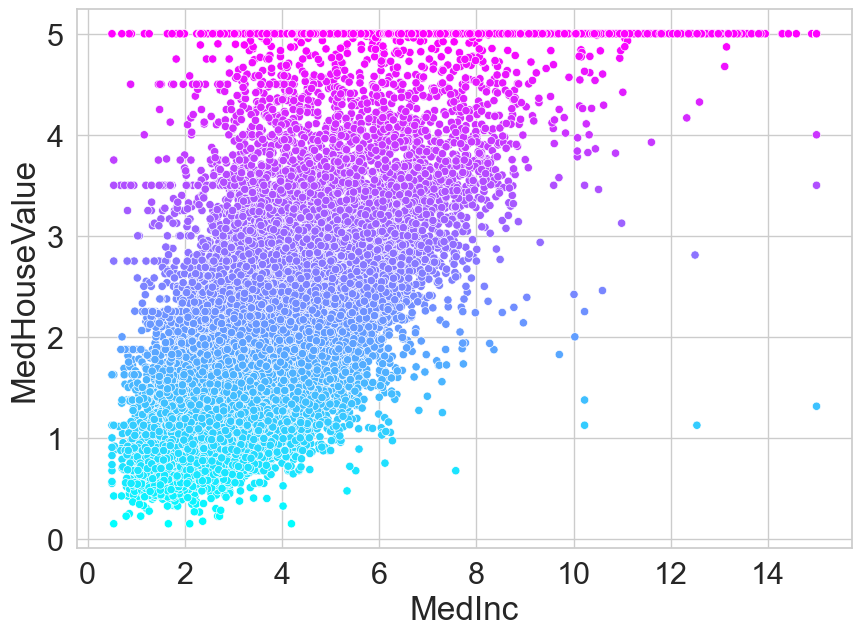

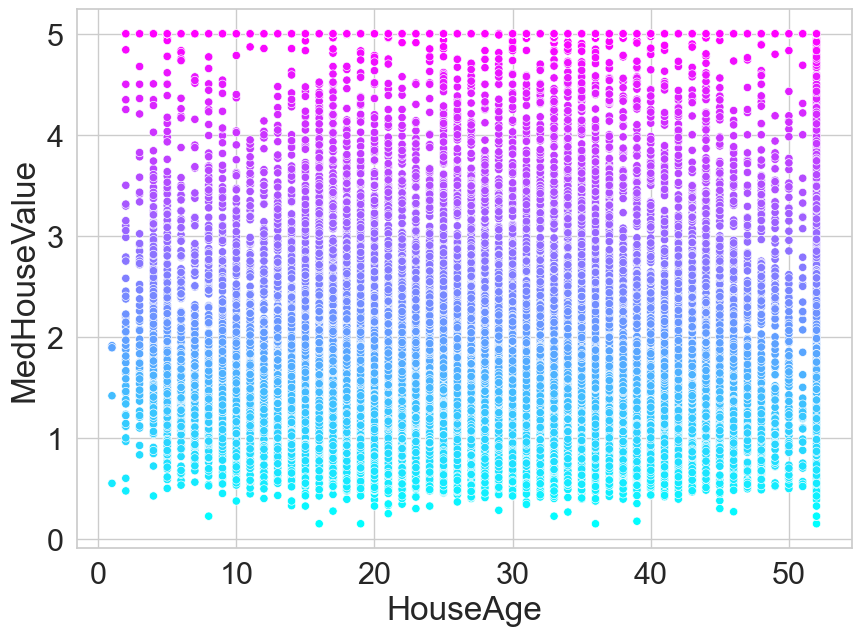

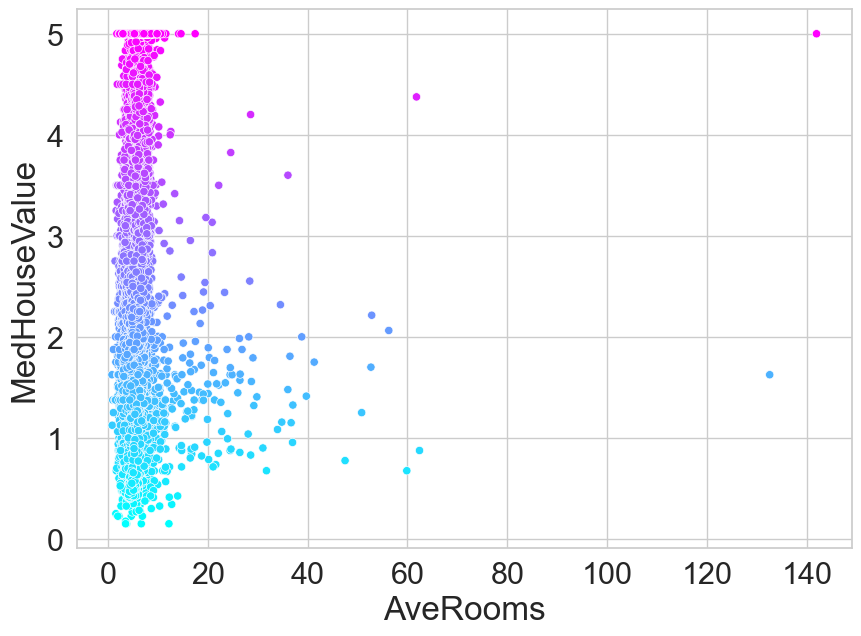

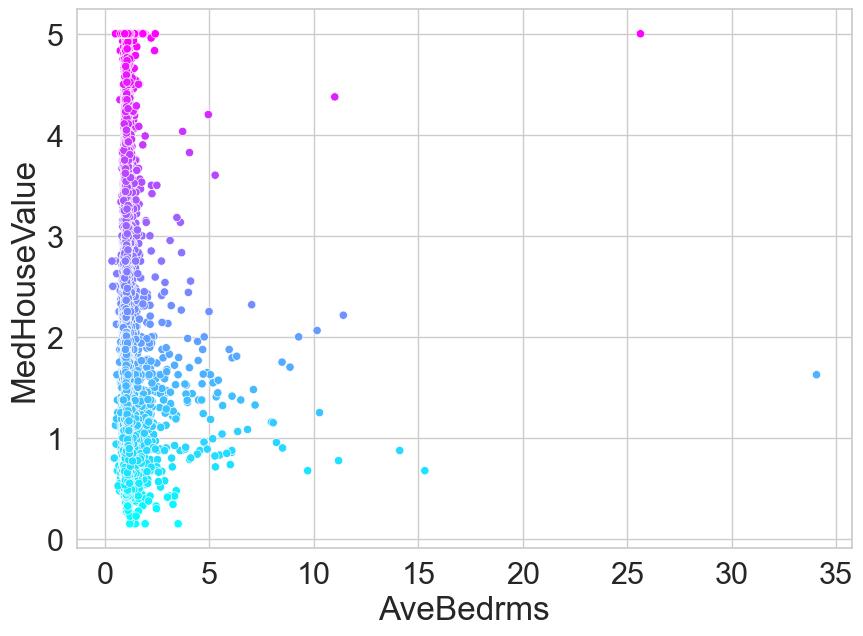

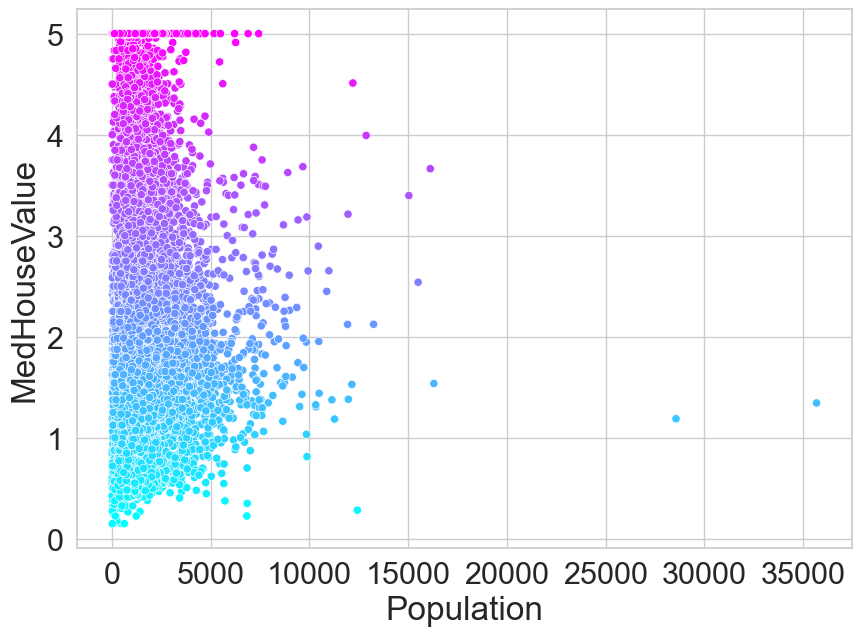

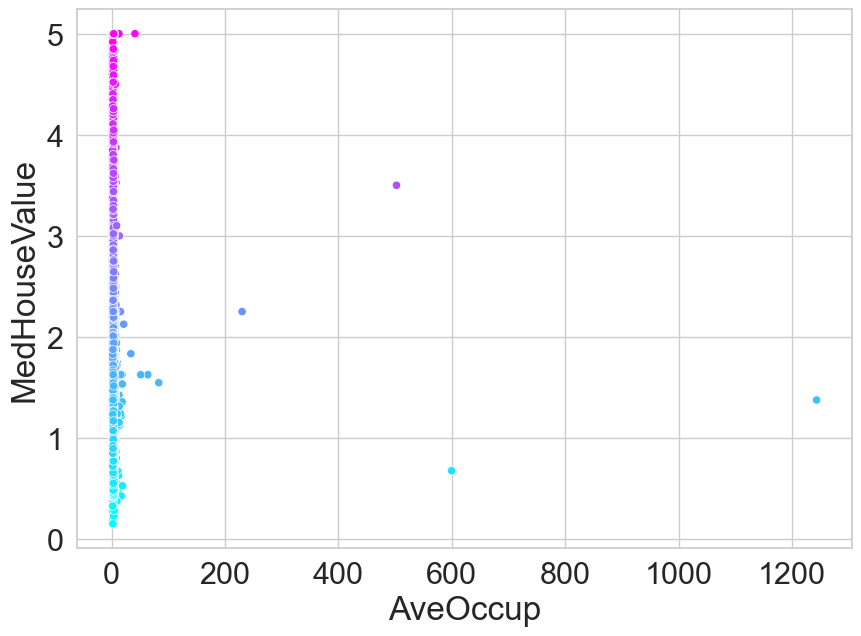

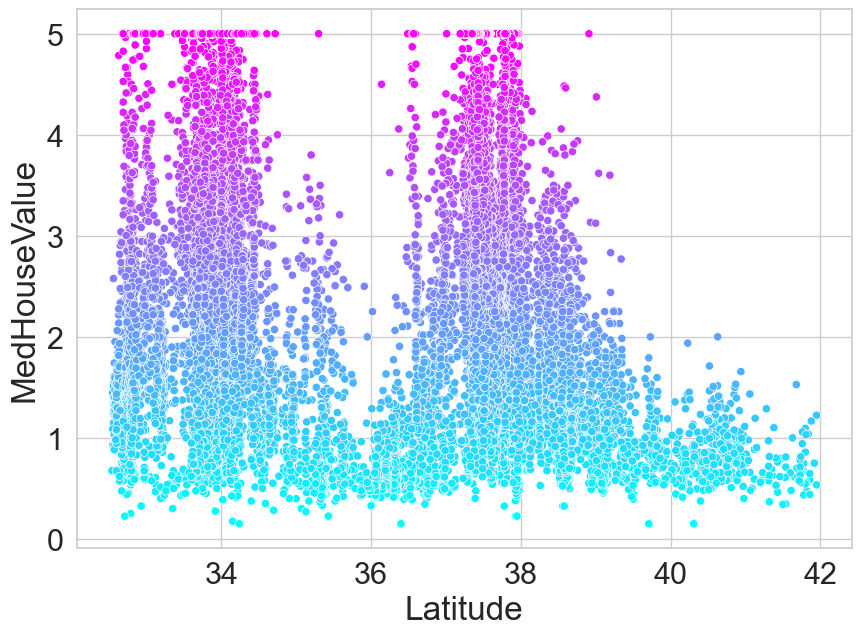

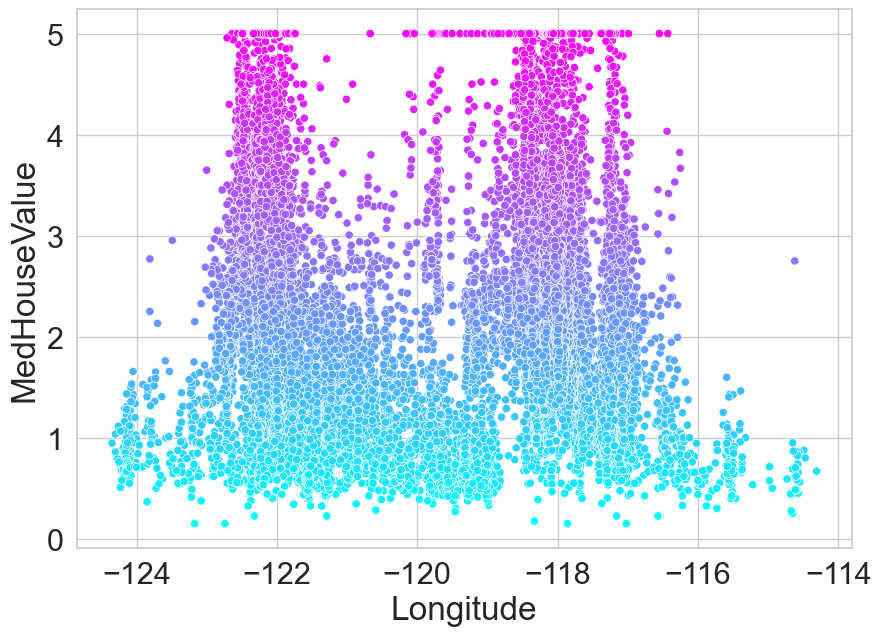

In [20]:
#using matplotlib for visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(font_scale=2)
sns.set_style('whitegrid')

for feature in california.feature_names:
    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=california_df, x=feature,y='MedHouseValue',
                    hue='MedHouseValue', palette='cool', legend=False)

## Preprocessing Tasks

In [21]:
# Check for null values
california_df.isnull().sum()

MedInc           0
HouseAge         0
AveRooms         0
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
MedHouseValue    0
dtype: int64

In [8]:
# Create two datasets for two datasets
import numpy as np

X = california_df.drop("MedHouseValue", axis=1)
y_reg = california_df["MedHouseValue"]

In [9]:
# Split datasets
from sklearn.model_selection import train_test_split

# X and y regression split
X_train, X_temp, y_reg_train, y_reg_temp = train_test_split(X, y_reg, test_size=0.4, random_state=42)
X_val, X_test, y_reg_val, y_reg_test = train_test_split(X_temp, y_reg_temp, test_size=0.5, random_state=42)

# y classification definition
threshold_cls = np.median(y_reg_train)

y_cls_train = (y_reg_train >= threshold_cls).astype(int)
y_cls_val = (y_reg_val >= threshold_cls).astype(int)
y_cls_test = (y_reg_test >= threshold_cls).astype(int)

In [10]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# replace outliers with median of that column
def handle_outliers(X, columns):
    X = X.copy()
    for col in columns:
        Q1 = X[col].quantile(0.25)
        Q3 = X[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        X[col] = np.where((X[col] > upper) | (X[col] < lower), np.median(X[col]), X[col])
    return X

# preprocess for model that don't need scaling
preprocess_noscaler = Pipeline(steps=[
    ('handle_outlier', FunctionTransformer(
        func=lambda X: handle_outliers(X, ['AveRooms', 'AveBedrms']),
        validate=False
    ))
])

# preprocess for models that need scaling
preprocess_withscaler = Pipeline(steps=[
    ('handle_outlier', FunctionTransformer(
        func=lambda X: handle_outliers(X, ['AveRooms', 'AveBedrms']),
        validate=False
    )),
    ('scaler', StandardScaler())
])

# 2 Regression

In [11]:
# evaluate regressors
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import r2_score

def evaluate_regressors(y_pred, y_test):
    rmse_error = np.sqrt(mean_squared_error(y_test, y_pred))

    mae_error = mae(y_test, y_pred)

    r2 = r2_score(y_test, y_pred)

    print("Root Mean Square Error (RMSE):", rmse_error)
    print("Mean Absolute Error (MAE):", mae_error)
    print("R2 Score:", r2)

In [24]:
# learning curve
import matplotlib.pyplot as plt 

def learning_curve(model):
    train_sizes = np.linspace(0.1, 1.0, 10)
    train_errors = []
    val_errors = []

    for frac in train_sizes:
        n_samples = int(frac * len(X_train))

        X_sub = X_train[:n_samples]
        y_sub = y_reg_train[:n_samples]

        model.fit(X_sub, y_sub)

        y_sub_pred = model.predict(X_sub)
        y_val_pred = model.predict(X_val)

        train_errors.append(mean_squared_error(y_sub, y_sub_pred))
        val_errors.append(mean_squared_error(y_reg_val, y_val_pred))
        
    plt.figure()
    plt.plot(train_sizes * len(X_train), train_errors, label="Training Error")
    plt.plot(train_sizes * len(X_train), val_errors, label="Validation Error")
    plt.xlabel("Training Set Size")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)
    plt.show()

## Linear Regression (base line)

Root Mean Square Error (RMSE): 0.7301660855019081
Mean Absolute Error (MAE): 0.536555311955712
R2 Score: 0.5915670424216635


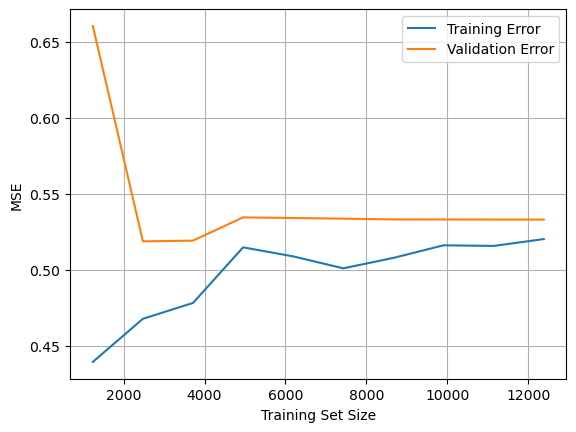

In [25]:
from sklearn.linear_model import LinearRegression

lr = Pipeline(steps=[
    ("preprocessor", preprocess_withscaler),
    ("classifier", LinearRegression())
])

lr.fit(X_train, y_reg_train)

y_lr_pred = lr.predict(X_val)

evaluate_regressors(y_lr_pred, y_reg_val)

learning_curve(lr)

## Ridge

In [16]:
#baseline
from sklearn.linear_model import Ridge

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocess_withscaler),
    ("classifier",  Ridge(alpha=100))
])

ridge_model.fit(X_train, y_reg_train)

y_ridge_pred = ridge_model.predict(X_val)

evaluate_regressors(y_ridge_pred, y_reg_val)

Root Mean Square Error (RMSE): 0.7307815784187388
Mean Absolute Error (MAE): 0.5365063268209184
R2 Score: 0.5908781757353899


Ridge model:
alpha: 10
Validation Rrror: 0.730161941827278
Train Error: 0.7213389615966297


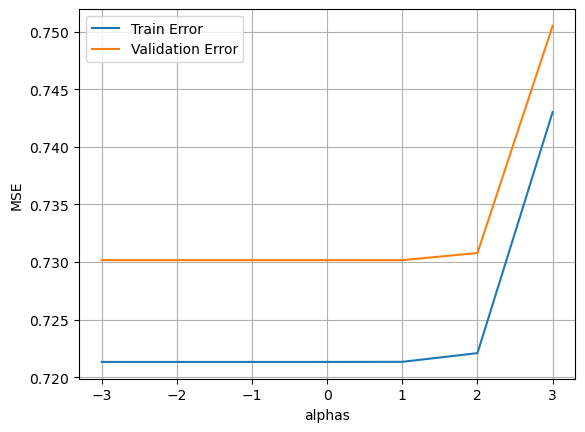

In [17]:
# alpha hyperparameter
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
val_errors = []
train_errors = []

for a in alphas:
    ridge_model = Pipeline(steps=[
        ("preprocessor", preprocess_withscaler),
        ("classifier",  Ridge(alpha=a))
    ])

    ridge_model.fit(X_train, y_reg_train)
    
    y_train_pred = ridge_model.predict(X_train)
    y_val_pred = ridge_model.predict(X_val)
    
    val_errors.append(np.sqrt(mean_squared_error(y_reg_val, y_val_pred)))
    train_errors.append(np.sqrt(mean_squared_error(y_reg_train, y_train_pred)))

min_err = np.argmin(val_errors)
print("Ridge model:")
print("alpha:", alphas[min_err])
print("Validation Rrror:", val_errors[min_err])
print("Train Error:", train_errors[min_err])
    
plt.figure()
plt.plot(np.log10(alphas), train_errors, label="Train Error")
plt.plot(np.log10(alphas), val_errors, label="Validation Error")
plt.xlabel("alphas")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

Validation Metrics:
Root Mean Square Error (RMSE): 0.730161941827278
Mean Absolute Error (MAE): 0.5364804421558584
R2 Score: 0.5915716781025471

Test Metrics:
Root Mean Square Error (RMSE): 0.7298300996701751
Mean Absolute Error (MAE): 0.5349504708669434
R2 Score: 0.611522154704357


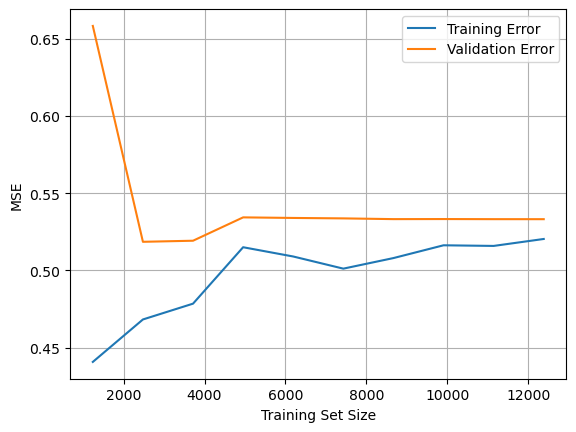

In [18]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocess_withscaler),
    ("classifier",  Ridge(alpha=10))
])

ridge_model.fit(X_train, y_reg_train)

y_val_pred = ridge_model.predict(X_val)

print("Validation Metrics:")
evaluate_regressors(y_val_pred, y_reg_val)

print()

y_test_pred = ridge_model.predict(X_test)

print("Test Metrics:")
evaluate_regressors(y_test_pred, y_reg_test)

learning_curve(ridge_model)

## Lasso

In [19]:
# baseline
from sklearn.linear_model import Lasso

lasso_model = Pipeline(steps=[
    ("preprocessor", preprocess_withscaler),
    ("classifier",  Lasso(alpha=100))
])

lasso_model.fit(X_train, y_reg_train)

y_lasso_pred = lasso_model.predict(X_val)

evaluate_regressors(y_lasso_pred, y_reg_val)

Root Mean Square Error (RMSE): 1.1425477021204906
Mean Absolute Error (MAE): 0.9039405240304442
R2 Score: -6.0208423507512876e-05


Lasso model:
alpha: 0.001
Validation Rrror: 0.7301764983719605
Train Error: 0.7213517113402865


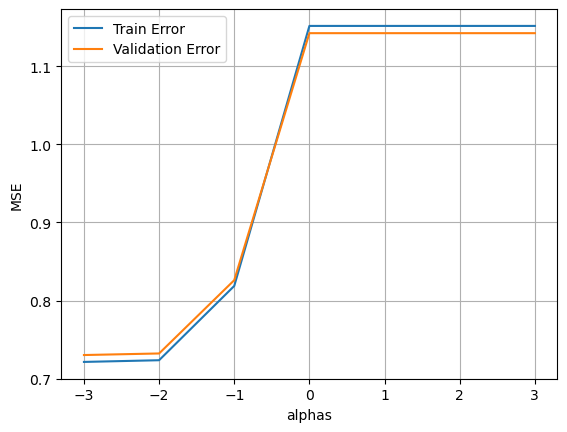

In [20]:
# alpha hyperparameter
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
val_errors = []
train_errors = []

for a in alphas:
    lasso_model = Pipeline(steps=[
        ("preprocessor", preprocess_withscaler),
        ("classifier",  Lasso(alpha=a))
    ])

    lasso_model.fit(X_train, y_reg_train)
    
    y_train_pred = lasso_model.predict(X_train)
    y_val_pred = lasso_model.predict(X_val)
    
    val_errors.append(np.sqrt(mean_squared_error(y_reg_val, y_val_pred)))
    train_errors.append(np.sqrt(mean_squared_error(y_reg_train, y_train_pred)))

min_err = np.argmin(val_errors)
print("Lasso model:")
print("alpha:", alphas[min_err])
print("Validation Rrror:", val_errors[min_err])
print("Train Error:", train_errors[min_err])
    
plt.figure()
plt.plot(np.log10(alphas), train_errors, label="Train Error")
plt.plot(np.log10(alphas), val_errors, label="Validation Error")
plt.xlabel("alphas")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

Validation Metrics:
Root Mean Square Error (RMSE): 0.7301764983719605
Mean Absolute Error (MAE): 0.5364749999044955
R2 Score: 0.5915553930456585

Test Metrics:
Root Mean Square Error (RMSE): 0.7298353612631623
Mean Absolute Error (MAE): 0.5349554925586414
R2 Score: 0.6115165533467933


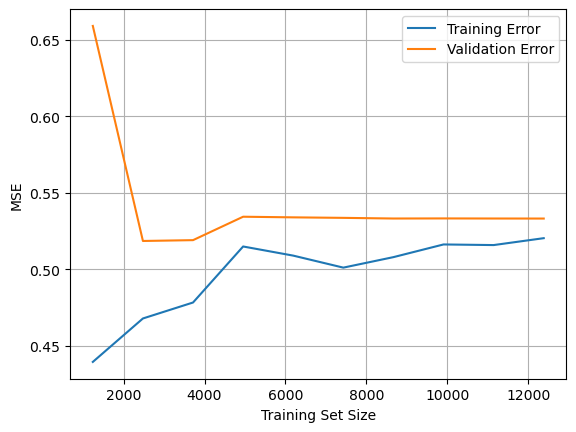

In [21]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline(steps=[
    ("preprocessor", preprocess_withscaler),
    ("classifier",  Lasso(alpha=0.001))
])

lasso_model.fit(X_train, y_reg_train)

y_val_pred = lasso_model.predict(X_val)

print("Validation Metrics:")
evaluate_regressors(y_val_pred, y_reg_val)

print()

y_test_pred = lasso_model.predict(X_test)

print("Test Metrics:")
evaluate_regressors(y_test_pred, y_reg_test)

learning_curve(lasso_model)

## Random Forest Regressor

In [49]:
# baseline
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocess_noscaler),
    ("classifier",  RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42))
])

rf_model.fit(X_train, y_reg_train)

rf_pred = rf_model.predict(X_val)

evaluate_regressors(rf_pred, y_reg_val)

Root Mean Square Error (RMSE): 0.5208218712669382
Mean Absolute Error (MAE): 0.34053054835271335
R2 Score: 0.7921950481929149


Best Random Forest model:
n_estimators: 800
Validation Rrror: 0.5180194786821768
Train Error: 0.18915766096194916


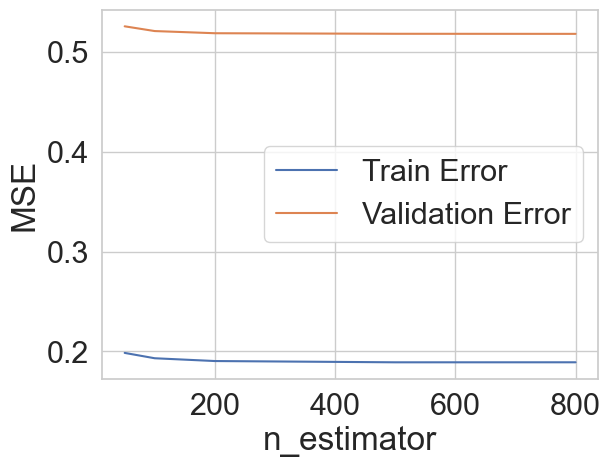

In [50]:
# n_estimators hyperparameter
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

n_estimators = [50, 100, 200, 500, 800]
val_errors = []
train_errors = []

for n in n_estimators:
    rf_model = Pipeline(steps=[
        ("preprocessor", preprocess_noscaler),
        ("classifier",  RandomForestRegressor(n_estimators=n, max_depth=None, random_state=42))
    ])

    rf_model.fit(X_train, y_reg_train)
    
    y_train_pred = rf_model.predict(X_train)
    y_val_pred = rf_model.predict(X_val)
    
    val_errors.append(np.sqrt(mean_squared_error(y_reg_val, y_val_pred)))
    train_errors.append(np.sqrt(mean_squared_error(y_reg_train, y_train_pred)))

min_err = np.argmin(val_errors)
print("Best Random Forest model:")
print("n_estimators:", n_estimators[min_err])
print("Validation Rrror:", val_errors[min_err])
print("Train Error:", train_errors[min_err])
    
plt.figure()
plt.plot(n_estimators, train_errors, label="Train Error")
plt.plot(n_estimators, val_errors, label="Validation Error")
plt.xlabel("n_estimator")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

Best Random Forest model:
max_depth: None
Validation Rrror: 0.5208218712669382
Train Error: 0.19319585631982988


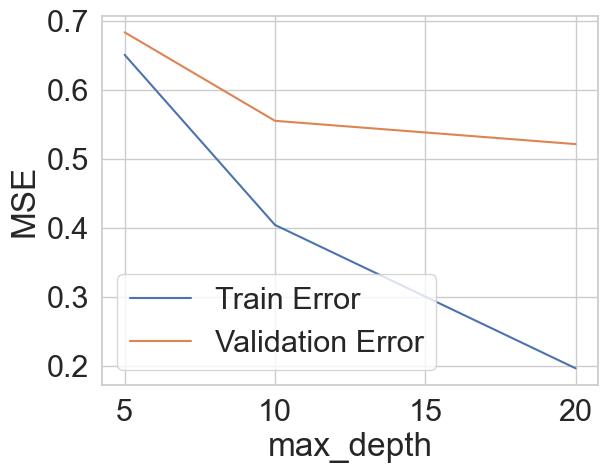

In [51]:
# max_depth hyperparameter
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

max_depth = [5, 10, 20, None]
val_errors = []
train_errors = []

for m in max_depth:
    rf_model = Pipeline(steps=[
        ("preprocessor", preprocess_noscaler),
        ("classifier",  RandomForestRegressor(n_estimators=100, max_depth=m, random_state=42))
    ])

    rf_model.fit(X_train, y_reg_train)
    
    y_train_pred = rf_model.predict(X_train)
    y_val_pred = rf_model.predict(X_val)
    
    val_errors.append(np.sqrt(mean_squared_error(y_reg_val, y_val_pred)))
    train_errors.append(np.sqrt(mean_squared_error(y_reg_train, y_train_pred)))

min_err = np.argmin(val_errors)
print("Best Random Forest model:")
print("max_depth:", max_depth[min_err])
print("Validation Rrror:", val_errors[min_err])
print("Train Error:", train_errors[min_err])
    
plt.figure()
plt.plot(max_depth, train_errors, label="Train Error")
plt.plot(max_depth, val_errors, label="Validation Error")
plt.xlabel("max_depth")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

Validation Metrics:
Root Mean Square Error (RMSE): 0.5549424548467669
Mean Absolute Error (MAE): 0.3770462713011149
R2 Score: 0.7640753241828636

Test Metrics:
Root Mean Square Error (RMSE): 0.5593287711133554
Mean Absolute Error (MAE): 0.37906452032947463
R2 Score: 0.7718307925257178


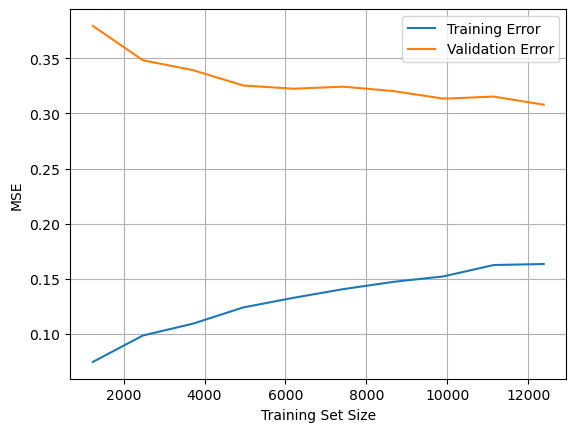

In [26]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocess_noscaler),
    ("classifier",  RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42))
])

rf_model.fit(X_train, y_reg_train)

y_val_pred = rf_model.predict(X_val)

print("Validation Metrics:")
evaluate_regressors(y_val_pred, y_reg_val)

print()

y_test_pred = rf_model.predict(X_test)

print("Test Metrics:")
evaluate_regressors(y_test_pred, y_reg_test)


learning_curve(rf_model)

# 3 Classification

In [7]:
from sklearn.metrics import f1_score, roc_auc_score

def evaluate_classifier(y_test, y_pred, predict_proba):
    f1 = f1_score(y_test, y_pred, average='macro')
    roc_auc = roc_auc_score(y_test, predict_proba)
    return f1, roc_auc

In [14]:
from sklearn.metrics import f1_score, roc_auc_score
import matplotlib.pyplot as plt

def learning_curve_classifier(model):
    train_sizes = np.linspace(0.1, 1.0, 10)
    train_score = []
    val_score = []

    for frac in train_sizes:
        n_samples = int(frac * len(X_train))

        X_sub = X_train[:n_samples]
        y_sub = y_cls_train[:n_samples]

        model.fit(X_sub, y_sub)

        y_sub_pred = model.predict(X_sub)
        y_val_pred = model.predict(X_val)

        train_score.append(f1_score(y_sub, y_sub_pred, average='macro'))
        val_score.append(f1_score(y_cls_val, y_val_pred, average='macro'))
        
    plt.figure(figsize=(10,10))
    plt.plot(train_sizes * len(X_train), train_score, label="Training Score")
    plt.plot(train_sizes * len(X_train), val_score, label="Validation Score")
    plt.xlabel("Training Set Size")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid(True)
    plt.show()

## Logisitic Regression (baseline)

Logistic Regression(baseline):
F1 score: 0.4854259805454376
roc_auc: 0.4811648693332331


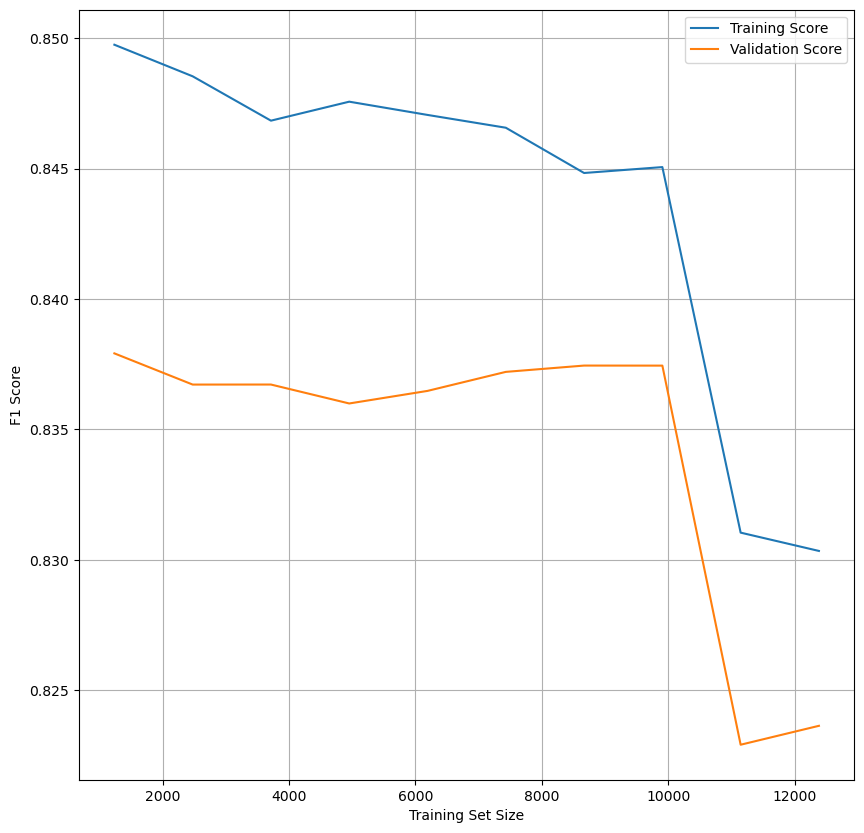

In [15]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=10000, random_state=42)
clf.fit(X_train, y_cls_train)

y_pred = clf.predict(X_val)

f1, roc_auc = evaluate_classifier(y_cls_test, y_pred, clf.predict_proba(X_val)[:, 1])

print("Logistic Regression(baseline):")
print("F1 score:", f1)
print("roc_auc:", roc_auc)

learning_curve_classifier(clf)

## Random Forest Classifier

In [11]:
# baseline
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocess_noscaler),
    ("classifier",  RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42))
])

rf_model.fit(X_train, y_cls_train)

rf_pred = rf_model.predict(X_val)

f1, roc_auc = evaluate_classifier(rf_pred, y_cls_val, rf_model.predict_proba(X_val)[:, 1])

print("Random Forest(baseline):")
print("F1 score:", f1)
print("roc_auc:", roc_auc)

Random Forest(baseline):
F1 score: 0.8890497364950021
roc_auc: 1.0


Best Random Forest model:
max_depth: 20
Validation Score: 0.8909879626673678
Train Score: 1.0


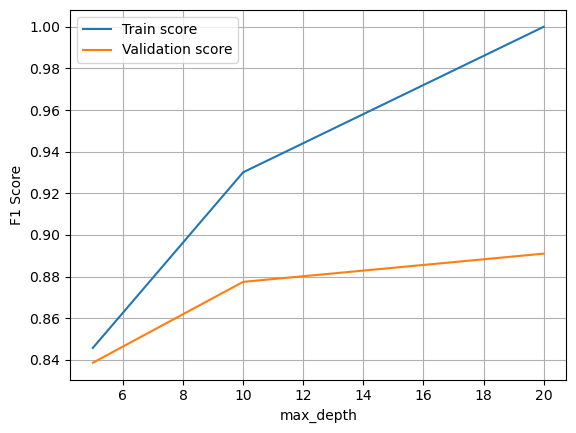

In [27]:
# max_depth hyperparameter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

max_depth = [5, 10, 20, None]
val_scores = []
train_scores = []

for m in max_depth:
    rf_model = Pipeline(steps=[
        ("preprocessor", preprocess_noscaler),
        ("classifier",  RandomForestClassifier(n_estimators=100, max_depth=m, random_state=42))
    ])

    rf_model.fit(X_train, y_cls_train)
    
    y_train_pred = rf_model.predict(X_train)
    y_val_pred = rf_model.predict(X_val)
    
    val_scores.append(f1_score(y_cls_val, y_val_pred, average='macro'))
    train_scores.append(f1_score(y_cls_train, y_train_pred, average='macro'))

max_score = np.argmax(val_scores)
print("Best Random Forest model:")
print("max_depth:", max_depth[max_score])
print("Validation Score:", val_scores[max_score])
print("Train Score:", train_scores[max_score])
    
plt.figure()
plt.plot(max_depth, train_scores, label="Train score")
plt.plot(max_depth, val_scores, label="Validation score")
plt.xlabel("max_depth")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)
plt.show()

Best Random Forest model:
n_estimators: 800
Validation Score: 0.8919571360866574
Train Score: 1.0


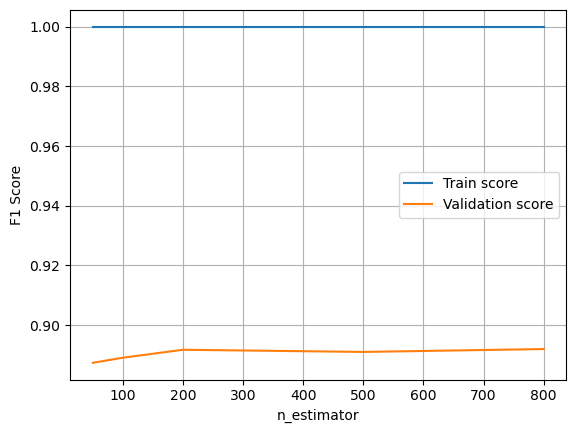

In [28]:
# n_estimators hyperparameter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

n_estimators = [50, 100, 200, 500, 800]
val_scores = []
train_scores = []

for n in n_estimators:
    rf_model = Pipeline(steps=[
        ("preprocessor", preprocess_noscaler),
        ("classifier",  RandomForestClassifier(n_estimators=n, max_depth=None, random_state=42))
    ])

    rf_model.fit(X_train, y_cls_train)
    
    y_train_pred = rf_model.predict(X_train)
    y_val_pred = rf_model.predict(X_val)
    
    val_scores.append(f1_score(y_cls_val, y_val_pred, average='macro'))
    train_scores.append(f1_score(y_cls_train, y_train_pred, average='macro'))

max_score = np.argmax(val_scores)
print("Best Random Forest model:")
print("n_estimators:", n_estimators[max_score])
print("Validation Score:", val_scores[max_score])
print("Train Score:", train_scores[max_score])
    
plt.figure()
plt.plot(n_estimators, train_scores, label="Train score")
plt.plot(n_estimators, val_scores, label="Validation score")
plt.xlabel("n_estimator")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)
plt.show()

Validation Metrics:
F1 score: 0.8793532151442307
roc_auc: 1.0

Test Metrics:
F1 score: 0.8795764170483387
roc_auc: 1.0


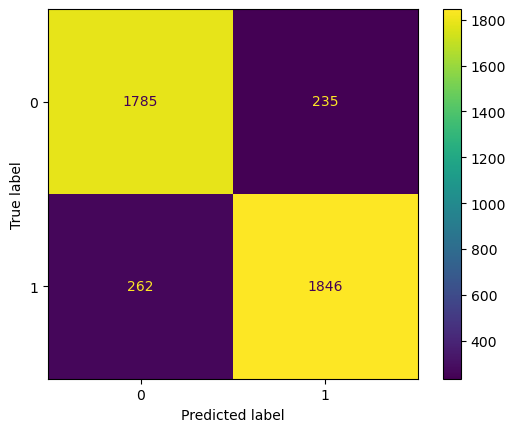

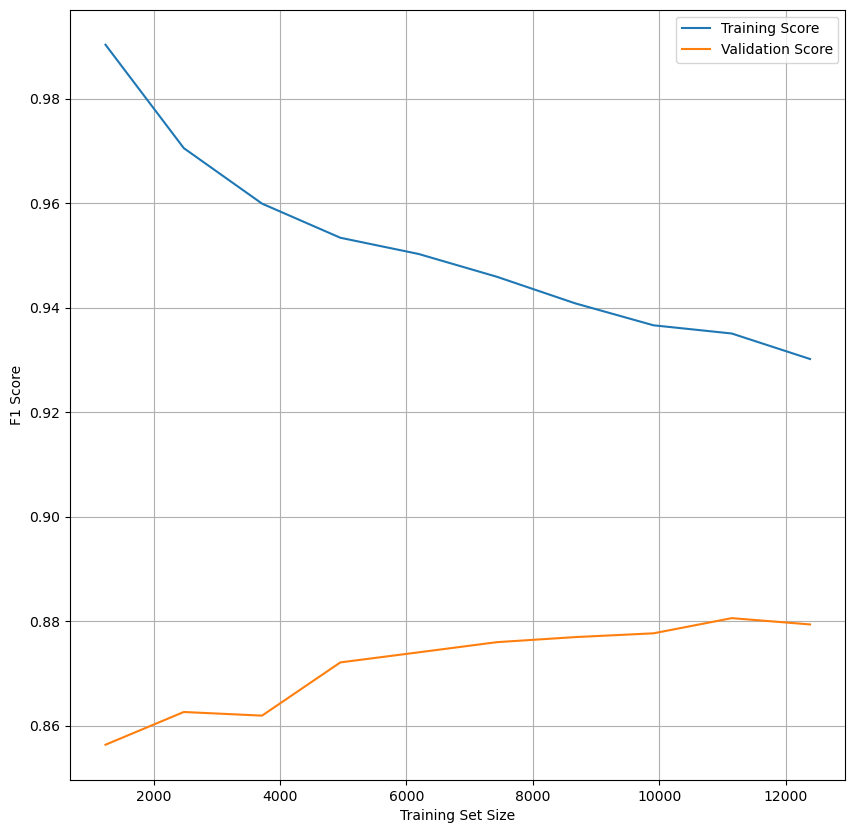

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

rf_model = Pipeline(steps=[
    ("preprocessor", preprocess_noscaler),
    ("classifier",  RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))
])

rf_model.fit(X_train, y_cls_train)

y_val_pred = rf_model.predict(X_val)

print("Validation Metrics:")
f1, roc_auc = evaluate_classifier(y_val_pred, y_cls_val, rf_model.predict_proba(X_val)[:, 1])
print("F1 score:", f1)
print("roc_auc:", roc_auc)

print()

y_test_pred = rf_model.predict(X_test)

print("Test Metrics:")
f1, roc_auc = evaluate_classifier(y_test_pred, y_cls_test, rf_model.predict_proba(X_test)[:, 1])
print("F1 score:", f1)
print("roc_auc:", roc_auc)

confusion_matrix = confusion_matrix(y_cls_test, y_test_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.show()

learning_curve_classifier(rf_model)

## Gradient Boosting Classifier

In [20]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline(steps=[
    ("preprocessor", preprocess_noscaler),
    ("classifier",  GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
])

gb_model.fit(X_train, y_cls_train)

gb_pred = gb_model.predict(X_val)

f1, roc_auc = evaluate_classifier(gb_pred, y_cls_val, gb_model.predict_proba(X_val)[:, 1])

print("Random Forest(baseline):")
print("F1 score:", f1)
print("roc_auc:", roc_auc)

Random Forest(baseline):
F1 score: 0.883720493511859
roc_auc: 0.9999999999999999


Best Random Forest model:
n_estimators: 500
Validation Score: 0.9052797570726893
Train Score: 0.9387106324656115


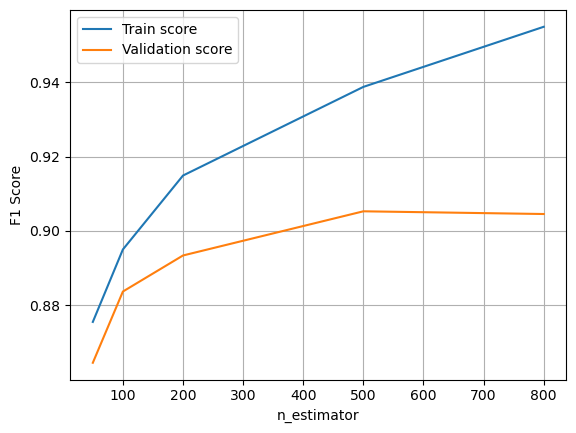

In [21]:
# n_estimators hyperparameter
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

n_estimators = [50, 100, 200, 500, 800]
val_scores = []
train_scores = []

for n in n_estimators:
    gb_model = Pipeline(steps=[
        ("preprocessor", preprocess_noscaler),
        ("classifier",  GradientBoostingClassifier(n_estimators=n, learning_rate=0.1, random_state=42))
    ])

    gb_model.fit(X_train, y_cls_train)
    
    y_train_pred = gb_model.predict(X_train)
    y_val_pred = gb_model.predict(X_val)
    
    val_scores.append(f1_score(y_cls_val, y_val_pred, average='macro'))
    train_scores.append(f1_score(y_cls_train, y_train_pred, average='macro'))

max_score = np.argmax(val_scores)
print("Best Random Forest model:")
print("n_estimators:", n_estimators[max_score])
print("Validation Score:", val_scores[max_score])
print("Train Score:", train_scores[max_score])
    
plt.figure()
plt.plot(n_estimators, train_scores, label="Train score")
plt.plot(n_estimators, val_scores, label="Validation score")
plt.xlabel("n_estimator")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)
plt.show()

Best Random Forest model:
n_estimators: 0.5
Validation Score: 0.9011613058305665
Train Score: 0.9391957360376368


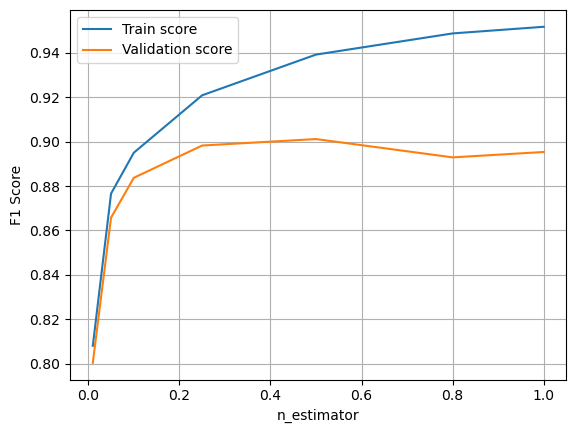

In [22]:
# learning_rate hyperparameter
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

learning_rates = [0.01, 0.05, 0.1, 0.25, 0.5, 0.8, 1.0]
val_scores = []
train_scores = []

for l in learning_rates:
    gb_model = Pipeline(steps=[
        ("preprocessor", preprocess_noscaler),
        ("classifier",  GradientBoostingClassifier(n_estimators=100, learning_rate=l, random_state=42))
    ])

    gb_model.fit(X_train, y_cls_train)
    
    y_train_pred = gb_model.predict(X_train)
    y_val_pred = gb_model.predict(X_val)
    
    val_scores.append(f1_score(y_cls_val, y_val_pred, average='macro'))
    train_scores.append(f1_score(y_cls_train, y_train_pred, average='macro'))

max_score = np.argmax(val_scores)
print("Best Random Forest model:")
print("n_estimators:", learning_rates[max_score])
print("Validation Score:", val_scores[max_score])
print("Train Score:", train_scores[max_score])
    
plt.figure()
plt.plot(learning_rates, train_scores, label="Train score")
plt.plot(learning_rates, val_scores, label="Validation score")
plt.xlabel("n_estimator")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True)
plt.show()

Validation Metrics:
F1 score: 0.9062453728952706
roc_auc: 1.0

Test Metrics:
F1 score: 0.8974876265851488
roc_auc: 1.0


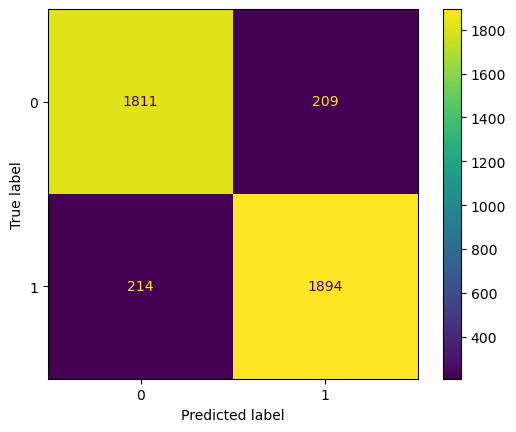

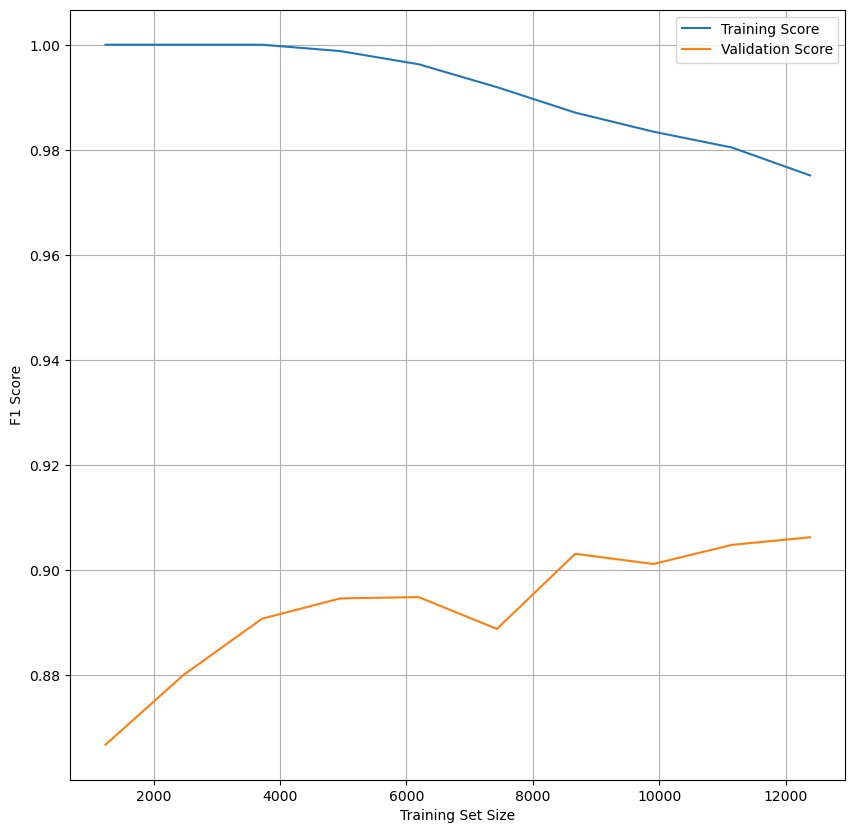

In [27]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

gb_model = Pipeline(steps=[
    ("preprocessor", preprocess_noscaler),
    ("classifier",  GradientBoostingClassifier(n_estimators=500, learning_rate=0.25, random_state=42))
])

gb_model.fit(X_train, y_cls_train)

y_val_pred = gb_model.predict(X_val)

print("Validation Metrics:")
f1, roc_auc = evaluate_classifier(y_val_pred, y_cls_val, gb_model.predict_proba(X_val)[:, 1])
print("F1 score:", f1)
print("roc_auc:", roc_auc)

print()

y_test_pred = gb_model.predict(X_test)

print("Test Metrics:")
f1, roc_auc = evaluate_classifier(y_test_pred, y_cls_test, gb_model.predict_proba(X_test)[:, 1])
print("F1 score:", f1)
print("roc_auc:", roc_auc)

confusion_matrix = confusion_matrix(y_cls_test, y_test_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.show()

learning_curve_classifier(gb_model)

# 3 SHAP

C:\ProgramData\miniconda3\envs\work\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Summary Plot (Beeswarm):


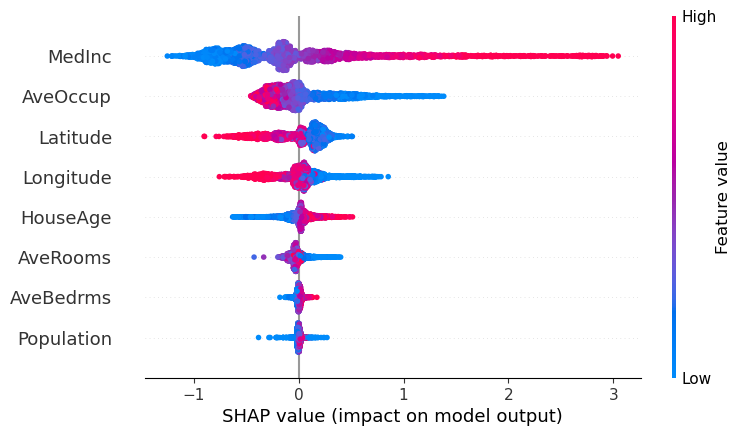

Summary Plot (Bar):


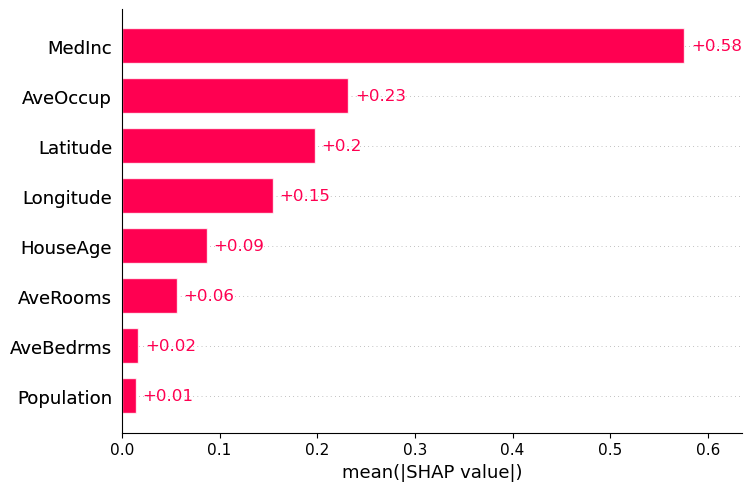

Dependence Plot:


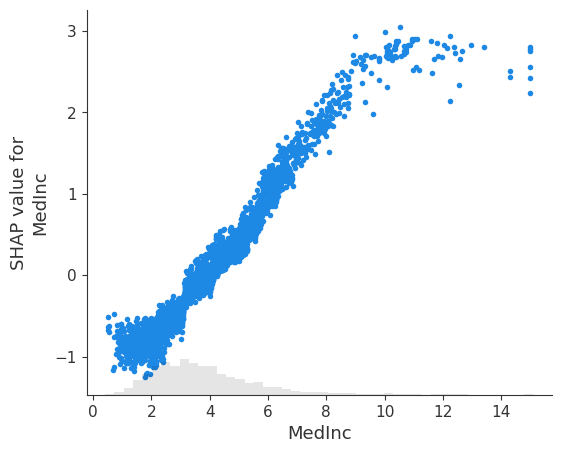

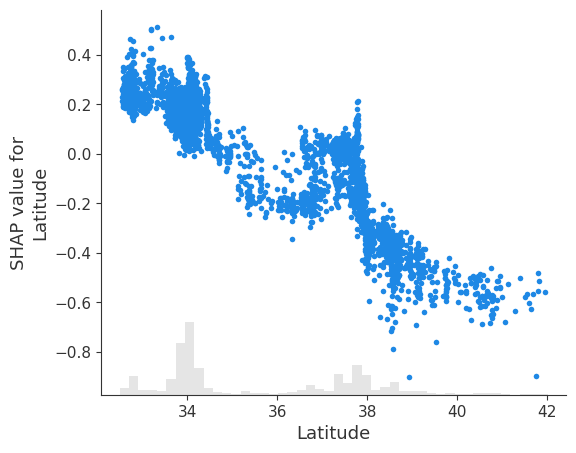

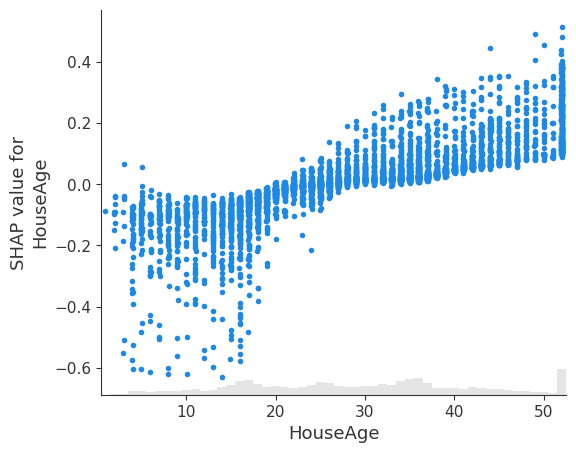

In [29]:
import shap
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor

X_train_scaled = preprocess_noscaler.fit_transform(X_train)
X_val_scaled = preprocess_noscaler.transform(X_val)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

rf_model.fit(X_train_scaled, y_reg_train)

explainer = shap.TreeExplainer(rf_model)
explanation = explainer(X_val_scaled)

shap_values = explainer.shap_values(X_val_scaled)

print("Summary Plot (Beeswarm):")
shap.plots.beeswarm(explanation)

print("Summary Plot (Bar):")
shap.plots.bar(explanation)


print("Dependence Plot:")
shap.plots.scatter(explanation[:, "MedInc"])
shap.plots.scatter(explanation[:, "Latitude"])
shap.plots.scatter(explanation[:, "HouseAge"])

In [40]:
print(y_reg_val.iloc[600])

1.2


In [41]:
from IPython.display import display
shap.initjs()
print("Force Plot:")
shap.plots.force(explanation[600])

Force Plot:


In [42]:
print(y_reg_val.iloc[40])

3.561


In [32]:
shap.plots.force(explanation[40])

In [43]:
print(y_reg_val.iloc[190])

1.38


In [33]:
shap.plots.force(explanation[190])

Summary Plot (Beeswarm):


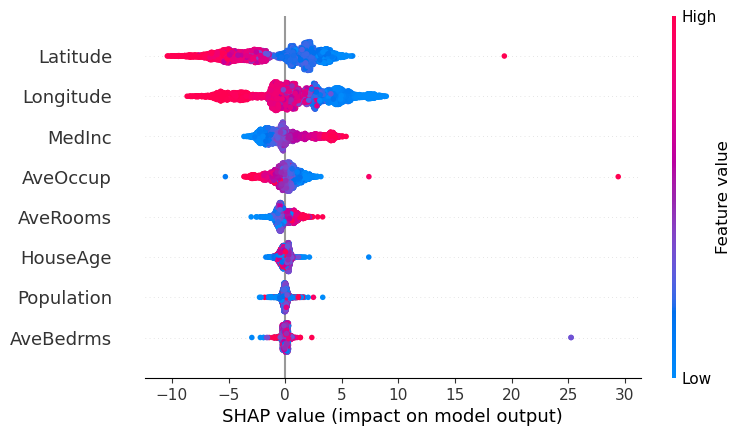

Summary Plot (Bar):


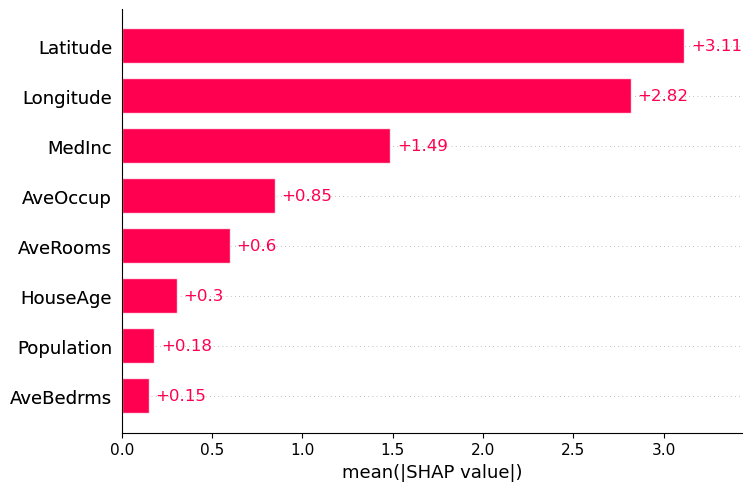

Dependence Plot:


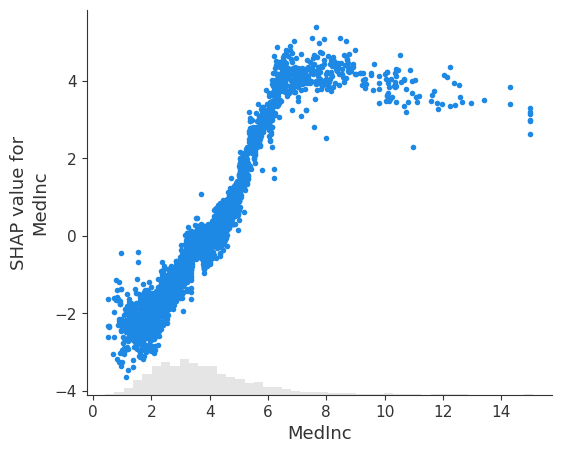

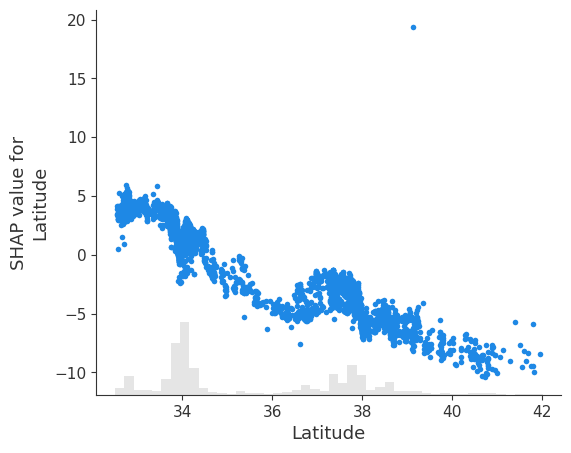

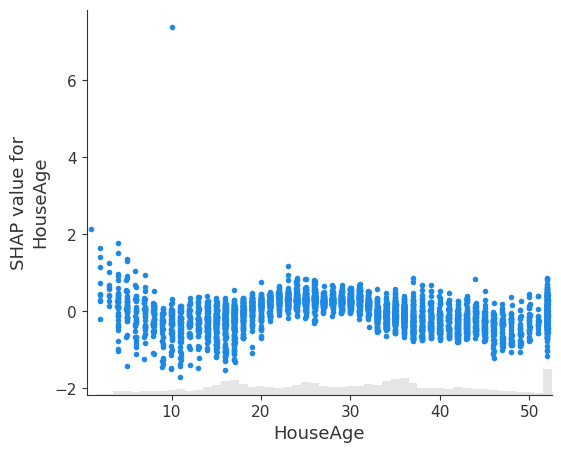

In [51]:
import shap
from sklearn.ensemble import GradientBoostingClassifier

X_train_scaled = preprocess_noscaler.fit_transform(X_train)
X_val_scaled = preprocess_noscaler.transform(X_val)

gb_model = GradientBoostingClassifier(n_estimators=500, learning_rate=0.25, random_state=42)

gb_model.fit(X_train_scaled, y_cls_train)


explainer = shap.TreeExplainer(gb_model)
explanation = explainer(X_val_scaled)

shap_values = explainer.shap_values(X_val_scaled)

print("Summary Plot (Beeswarm):")
shap.plots.beeswarm(explanation)

print("Summary Plot (Bar):")
shap.plots.bar(explanation)


print("Dependence Plot:")
shap.plots.scatter(explanation[:, "MedInc"])
shap.plots.scatter(explanation[:, "Latitude"])
shap.plots.scatter(explanation[:, "HouseAge"])

In [62]:
import numpy as np

log_odds = explanation[400].values.sum() + explanation[600].base_values
prob = 1 / (1 + np.exp(-log_odds))
print(prob)
print(y_cls_val.iloc[400])

0.7800539376843109
0


In [63]:
from IPython.display import display

print("Force Plot:")
shap.plots.force(explanation[400])

Force Plot:


In [57]:
import numpy as np

log_odds = explanation[40].values.sum() + explanation[600].base_values
prob = 1 / (1 + np.exp(-log_odds))
print(prob)
print(y_cls_val.iloc[40])

0.9997992654226507
1


In [58]:
shap.plots.force(explanation[40])

In [59]:
import numpy as np

log_odds = explanation[190].values.sum() + explanation[600].base_values
prob = 1 / (1 + np.exp(-log_odds))
print(prob)
print(y_cls_val.iloc[190])

0.3918439986279763
0


In [60]:
shap.plots.force(explanation[190])

# 4 PCA

In [38]:
from sklearn.decomposition import PCA

pca = Pipeline(steps=[
    ("preprocessor", preprocess_noscaler),
    ("PCA", PCA(n_components=0.95)) 
])

X_train_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)
X_val_reduced = pca.transform(X_val)

Validation Metrics:
Root Mean Square Error (RMSE): 1.1482082949052643
Mean Absolute Error (MAE): 0.9057755651387124
R2 Score: -0.009994072438952228

Test Metrics:
Root Mean Square Error (RMSE): 1.1726181479949367
Mean Absolute Error (MAE): 0.9216935492852164
R2 Score: -0.002849904708823958


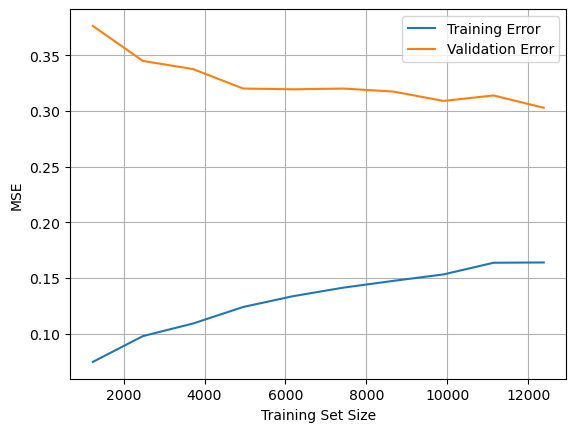

In [39]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("classifier",  RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42))
])

rf_model.fit(X_train_reduced, y_reg_train)

y_val_pred = rf_model.predict(X_val_reduced)

print("Validation Metrics:")
evaluate_regressors(y_val_pred, y_reg_val)

print()

y_test_pred = rf_model.predict(X_test_reduced)

print("Test Metrics:")
evaluate_regressors(y_test_pred, y_reg_test)


learning_curve(rf_model)

Validation Metrics:
F1 score: 0.4964102371236766
roc_auc: 1.0

Test Metrics:
F1 score: 0.4980594058241061
roc_auc: 1.0


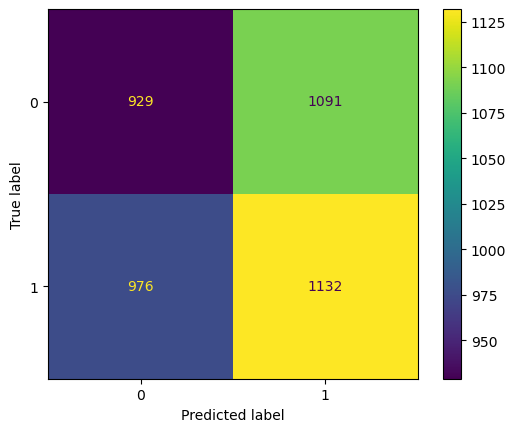

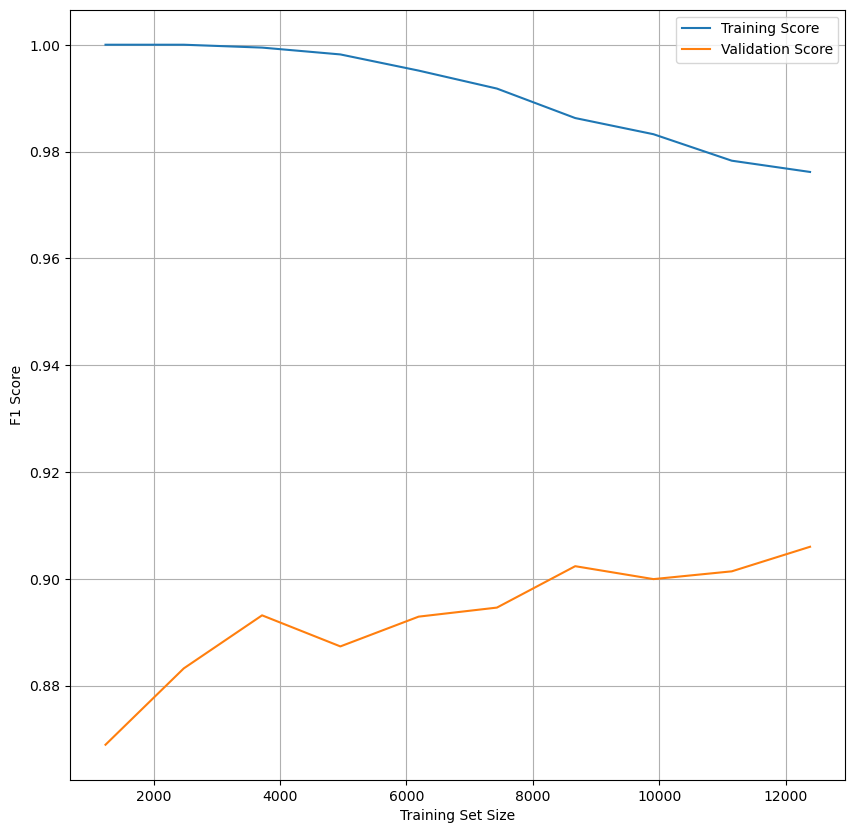

In [41]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

gb_model = Pipeline(steps=[
    ("classifier",  GradientBoostingClassifier(n_estimators=500, learning_rate=0.25, random_state=42))
])

gb_model.fit(X_train_reduced, y_cls_train)

y_val_pred = gb_model.predict(X_val_reduced)

print("Validation Metrics:")
f1, roc_auc = evaluate_classifier(y_val_pred, y_cls_val, gb_model.predict_proba(X_val_reduced)[:, 1])
print("F1 score:", f1)
print("roc_auc:", roc_auc)

print()

y_test_pred = gb_model.predict(X_test_reduced)

print("Test Metrics:")
f1, roc_auc = evaluate_classifier(y_test_pred, y_cls_test, gb_model.predict_proba(X_test_reduced)[:, 1])
print("F1 score:", f1)
print("roc_auc:", roc_auc)

confusion_matrix = confusion_matrix(y_cls_test, y_test_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
cm_display.plot()
plt.show()

learning_curve_classifier(gb_model)